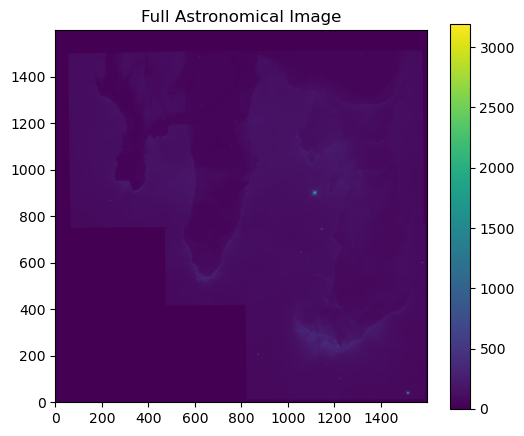

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("astro_image.csv")

plt.figure(figsize=(6, 5))
plt.imshow(data, origin="lower", cmap="viridis")
plt.colorbar()
plt.title("Full Astronomical Image")
plt.show()


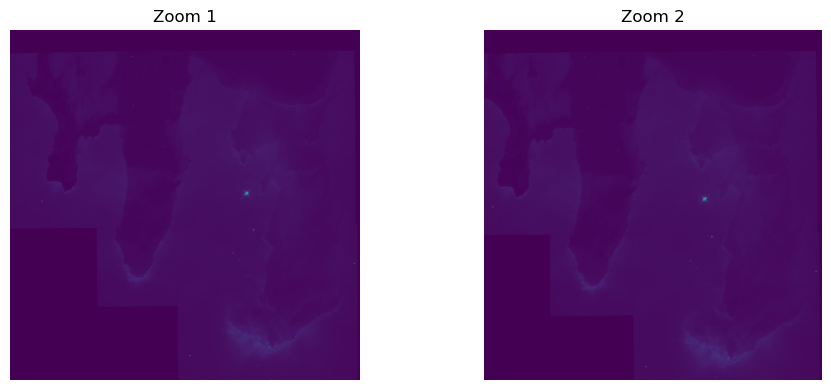

In [6]:
zoom1 = data[100:2000, 100:2000]
zoom2 = data[150:2500, 200:3000]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(zoom1, origin="lower", cmap="viridis")
axes[0].set_title("Zoom 1")
axes[0].axis("off")

axes[1].imshow(zoom2, origin="lower", cmap="viridis")
axes[1].set_title("Zoom 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
#1. Column names
#df.columns

#2. Ramen style of the 27th entry
#27th entry = row 26
#df.iloc[26]["Style"]

#3. How many different ramen brands are there?
#df["Brand"].nunique()

#4. Sort the dataset by brand names
#df_sorted = df.sort_values("Brand")
#df_sorted.head()

#5. How many ramen brands are made in the USA?
#usa_brands = df[df["Country"] == "USA"]["Brand"].nunique()
#usa_brands

#6. How many ramen brands in the USA make pack-style ramen?
#usa_pack_brands = df[(df["Country"] == "USA") & (df["Style"] == "Pack")]["Brand"].nunique()
#usa_pack_brands

#7. Challenge: Which ramen brands have been in the top ten?
#top_ten_brands = df[df["Top Ten"].notna()]["Brand"].unique()
#3top_ten_brands

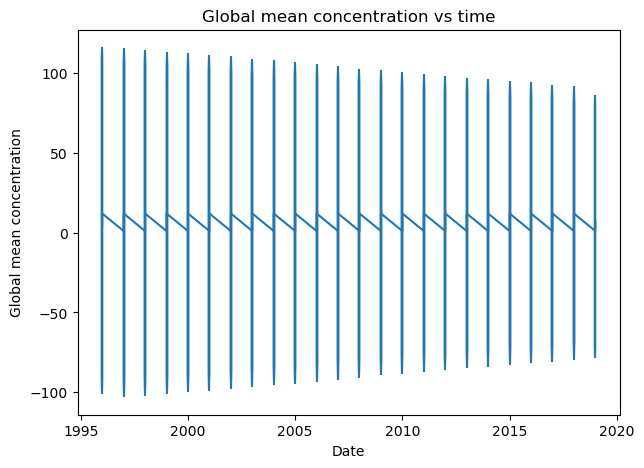

np.float64(0.0014226161538070695)

In [33]:
from astropy.table import Table
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

t = Table.read("global_CCl4_MM.dat", format="ascii")

df_cc = t.to_pandas()
df_cc = df_cc.iloc[:, :3]
df_cc.columns = ["date", "global mean concentration", "global mean concentration sd"]
df_cc.head()

x = df_cc["date"].to_numpy()
y = df_cc["global mean concentration"].to_numpy()
yerr = df_cc["global mean concentration sd"].to_numpy()

mask = (~np.isnan(x)) & (~np.isnan(y)) & (~np.isnan(yerr))
x = x[mask]
y = y[mask]
yerr = yerr[mask]

plt.figure(figsize=(7, 5))
plt.errorbar(x, y, yerr=yerr)
plt.xlabel("Date")
plt.ylabel("Global mean concentration")
plt.title("Global mean concentration vs time")
plt.legend
plt.show()

m, b = np.polyfit(x, y, 1)
y_fit = m * x + b

residuals = y - y_fit
chi2 = np.sum((residuals / yerr) ** 2)
dof = len(x) - 2
chi2_red = chi2 / dof
chi2_red